In [1]:
import numpy as np
import cvxpy as cp
import time
import matplotlib.pyplot as plt
from matplotlib import cm, ticker, transforms
import matplotlib.colors as mcolors
from types import DynamicClassAttribute
import math
import matplotlib.patches as patches
#import sympy as sp
from itertools import combinations_with_replacement, product
#from scipy import linalg
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from matplotlib.colors import LogNorm

from functools import reduce
import operator

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

Unknown-model barrier

In [3]:
def phi(qmax, q):
    q = np.array(q)
    qmax = np.array(qmax)
    return qmax * (1 - np.exp(-q))


def fdt(x, u=0):
    x = np.array(x)
    u = np.array(u)
    n = len(x)
    
    R = np.zeros((n, n))
    R[0, 1] = u[1]#np.round(np.random.uniform(0.05, 0.15), 2)
    
    Fin = np.zeros(n)
    Fin[0] = u[0]
    
    #xmax = np.concatenate([[1.01*Fin[0]], 9*np.ones(n-1)])
    xmax = np.ones(n) * 10
    g = (x <= 1 * xmax).astype(float)
    R = R * g 
    
    tau = 0.01
    x = x + tau * (Fin - (np.eye(n) - R.T).dot(phi(xmax, x)))
    return x

def dynsys(x0, U, T=1, rounding=64):
    x0 = np.array(x0)
    U = np.array(U)
    x = []
    
    for j in range(T):
        x.append(x0)
        x0 = fdt(x0, U[j])
        
    return np.round(x, rounding)

# Define simulation parameters
T_steps = 1000
u1 = np.array([9, 0.2])  # Constant control input for testing
u2 = np.array([9, 0.6])  # Another constant control input for testing
u3 = np.array([10, 0.5])  # Another constant control input for testing
# Create control input sequence alternating between u1 and u2

U_test = np.tile(u2, (T_steps, 1))

# U_test = np.empty((T_steps, u1.size))
# # U_test[0::2] = u1 # even indices: 0,2,4,...
# # U_test[1::2] = u2 # odd indices: 1,3,5,...
# block_len = 9  # Length of each block of constant control input
# block_idx = np.arange(T_steps) // block_len
# U_test[block_idx % 3 == 0] = u3
# U_test[block_idx % 3 == 1] = u3
# U_test[block_idx % 3 == 2] = u3

# # Generate random initial states
#np.random.seed(42)
# x0_test = np.random.uniform(7.0, 9.0, size=2)

# # Run system
# state_history = dynsys(x0_test, U_test, T=T_steps, rounding=4)

# # Convert to numpy array for easier plotting
# state_history_np = np.array(state_history)

# # Plot
# plt.plot(state_history_np)
# plt.title(f'System State Dynamics Over {T_steps} Time Steps')
# plt.xlabel('Time Step')
# plt.ylabel('State Value (x)')
# plt.legend([f'Node {i}' for i in range(state_history_np.shape[1])], loc='best')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# #plt.savefig('state_history.pdf')
# print()
# print('Initial conditions:', state_history_np[0])
# print('Final conditions:', state_history_np[-1])
# print(U_test[0:5])


Initial conditions traj0: [9.5 9.9]
Final conditions traj0: [2.3612 0.7859]

Initial conditions traj1: [0.1 0.3]
Final conditions traj1: [2.3025 0.5978]


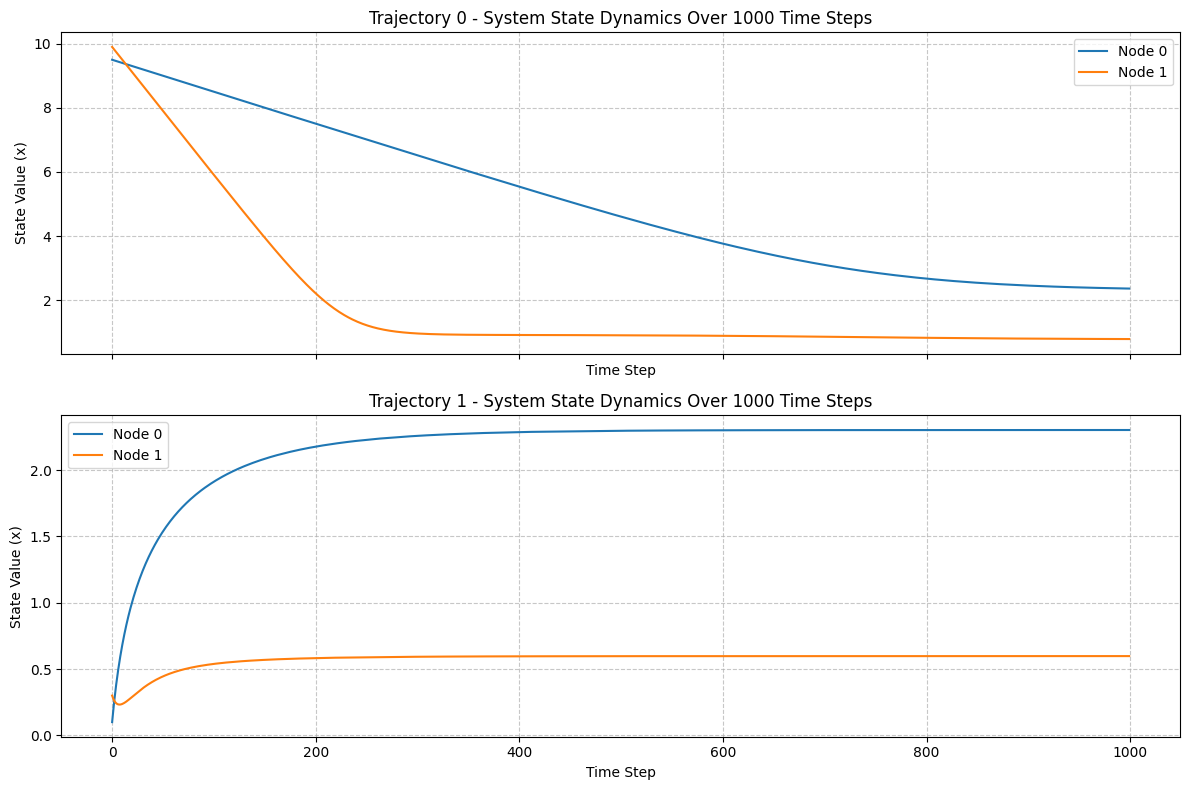

Granularity of Barrier grid:  0.2
X dimension (51, 51, 2) 
 fT dimension (4, 51, 51) 
trajectory dimension (2, 1000, 2) 
input_u dimension (2, 1000, 2)
Time taken for barrier computation: 1.01 seconds


In [ ]:
# Test trajectories
dim = 2 # Dimension of the state space
dim_input = 2 # Dimension of the input space
# Parameters
round = 4
gain = 10
granularity = 1
bounds = [(0, 10)]*dim
U = np.array([0.0,0.99])  # Control inputs

NSol = 2
T_steps = 1000
#x0 = np.array(np.round(np.random.uniform(-7,7,(NSol,dim)),1))#(np.random.rand(NSol,dim)+1))
x0 = np.array([[9.5,9.9],[0.1,0.3]])#,[5.2,4.5]])
#x0 = np.array([[-3.0,-5.0],[5.2,-5.2],[-5.2,5.2],[6,0.5],[5.6,6.5],[1.5,5.4]])
#x0 = np.array([9.5066, 9.8984, 9.1905, 9.4622, 9.062])

u1 = np.array([0.15, 0.26])  # Constant control input for testing
u2 = np.array([9, 0.5])  # Another constant control input for testing
u3 = np.array([9, 0.6])  # Another constant control input for testing

# Create control input sequence for each trajectory.
# Each input has shape (dim_input, T_steps), and NSol trajectories are stacked along axis 2.
input_u1 = np.tile(u3, (T_steps, 1))
input_u2 = np.tile(u2, (T_steps, 1))
input_u = np.stack([input_u1.T, input_u2.T], axis=2)  # shape: (dim_input, T_steps, NSol)

# Simulate trajectories and store them in shape: (dim, T_steps, NSol)
traj1 = dynsys(x0[0], input_u1, T=T_steps, rounding=round)
traj2 = dynsys(x0[1], input_u2, T=T_steps, rounding=round)
trajectory = np.stack([traj1.T, traj2.T], axis=2)

# Plot trajectories in subplots
fig, axes = plt.subplots(NSol, 1, figsize=(12, 4*NSol), sharex=True)

timestart = time.time()
# Handle case when NSol == 1 (axes is not an array)
if NSol == 1:
    axes = [axes]

for traj in range(NSol):
    axes[traj].plot(trajectory[:, :, traj].T)
    axes[traj].set_title(f'Trajectory {traj} - System State Dynamics Over {T_steps} Time Steps')
    axes[traj].set_xlabel('Time Step')
    axes[traj].set_ylabel('State Value (x)')
    axes[traj].legend([f'Node {i}' for i in range(dim)], loc='best')
    axes[traj].grid(True, linestyle='--', alpha=0.7)
    
    print()
    print(f'Initial conditions traj{traj}:', trajectory[:, 0, traj])
    print(f'Final conditions traj{traj}:', trajectory[:, -1, traj])

plt.tight_layout()
plt.show()

## Create grid and compute PP and QQ
axis_vectors = [np.arange(b[0], b[1] + granularity, granularity) for b in bounds]
grids = np.meshgrid(*axis_vectors)
X = np.stack(grids, axis=-1)
grid_shape = X.shape[:-1]

# ==========================================
# 0. ROBUST PREPARATION OF ARRAYS
# ==========================================

# 1. Safety check for trajectory shape
if trajectory.ndim != 3 or trajectory.shape != (dim, T_steps, NSol):
    raise ValueError(f"Unexpected trajectory shape: {trajectory.shape}. Expected (dim, T_steps, NSol).")


# ==========================================
# 1. LOWER AND UPPER BARRIER INITIALIZATION & LOOP
# ==========================================

fP = np.full((NSol, *grid_shape), gain * 1.1, dtype=float)
fQ = np.full((NSol, *grid_shape), gain * 1.1, dtype=float)

for t in range(T_steps):
    # Grab trajectory at time t and reshape for grid broadcasting
    traj_at_t = trajectory[:, t, :].T  # shape: (NSol, dim)
    traj_expanded = traj_at_t.reshape(NSol, *[1]*len(grid_shape), dim)
    
    # Masks for lower and upper barrier conditions
    mask_low = np.all(X[None, ...] <= traj_expanded, axis=-1)
    mask_high = np.all(X[None, ...] >= traj_expanded, axis=-1)
    
    update_vals = np.round(gain * 1.0 / (1 + t), round)
    
    fP = np.where(mask_low & (update_vals < fP), update_vals, fP)
    fQ = np.where(mask_high & (update_vals < fQ), update_vals, fQ)


# ==========================================
# 3. CONCATENATION & VERIFICATION
# ==========================================

fT = np.concatenate([fP, fQ], axis=0)

print("Granularity of Barrier grid: ", granularity)
print("X dimension", X.shape, "\n fT dimension", fT.shape, "\ntrajectory dimension", trajectory.shape, "\ninput_u dimension", input_u.shape)
timeend = time.time()
print('Time taken for barrier computation: {:.2f} seconds'.format(timeend - timestart))

In [5]:
## Safety problem: State Set, Initial Set, Unsafe Set, 
#Initial Set
x0lb = [4]*dim
x0ub = [6]*dim

# Unsafe sets for every dimension: one interval [0,10] in one dimension and full range in the others.
xUlb_list = [np.array([0.0 if j == i else 9.0 for j in range(dim)]) for i in range(dim)]
xUub_list = [np.array([10.0]*dim) for _ in range(dim)]

# Add an extra unsafe box covering the small hypercube [0,0,0,0,0] to [1,1,1,1,1].
xUlb_list.append(np.zeros(dim, dtype=float))
xUub_list.append(np.ones(dim, dtype=float))

# Preserve the first two unsafe sets for backward compatibility.
xUlb = xUlb_list[0]
xUub = xUub_list[0]
xUlb2 = xUlb_list[1] if dim > 1 else xUlb_list[0]
xUub2 = xUub_list[1] if dim > 1 else xUub_list[0]
for idx, (lb, ub) in enumerate(zip(xUlb_list, xUub_list), start=1):
    print(f"Unsafe set {idx}: xUlb = {lb}, xUub = {ub}")


Unsafe set 1: xUlb = [0. 9.], xUub = [10. 10.]
Unsafe set 2: xUlb = [9. 0.], xUub = [10. 10.]
Unsafe set 3: xUlb = [0. 0.], xUub = [1. 1.]


Basis function: fP . Trajectory: 0


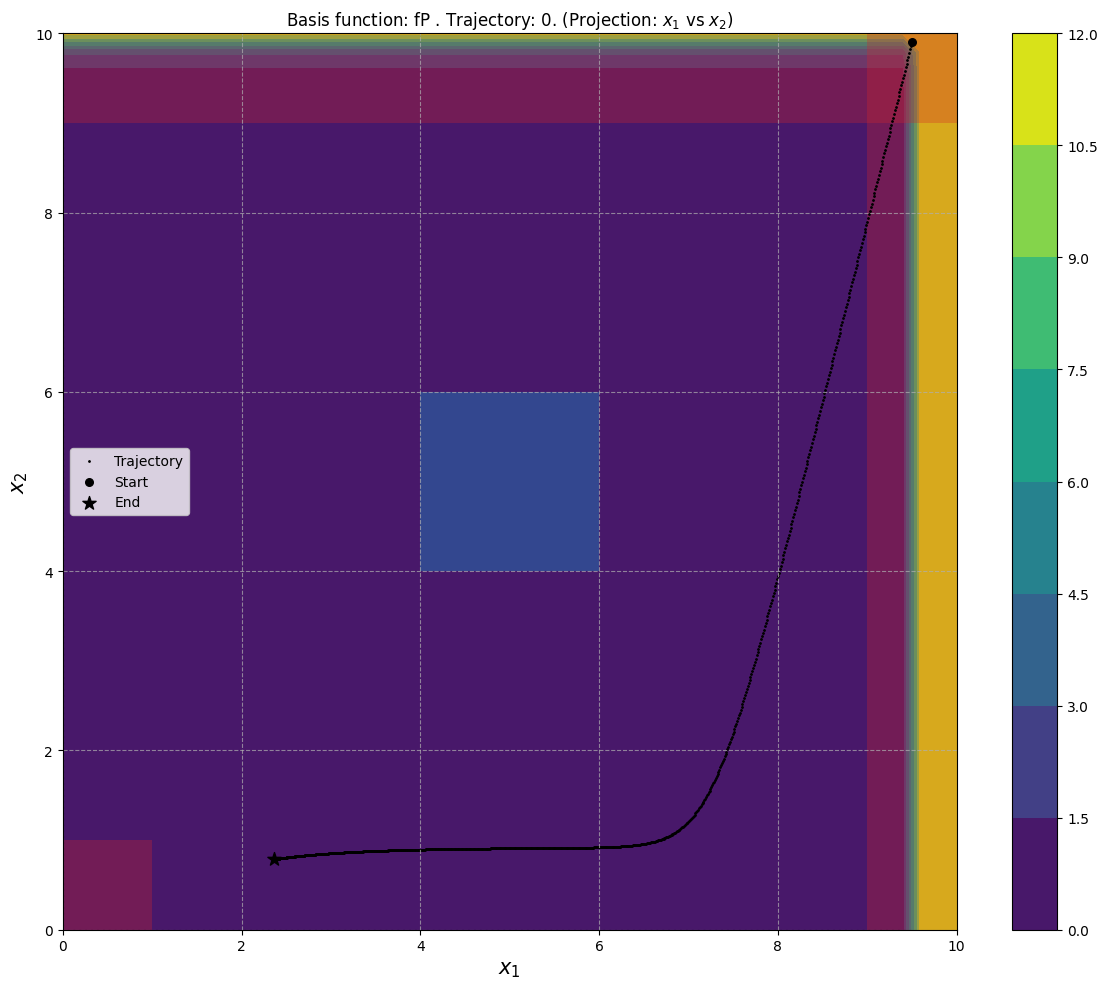

In [6]:

fig2 = plt.figure(figsize=(12, 10))

idx = np.random.randint(0, 2*NSol)
basisfcn = 'fQ' if idx >= NSol else 'fP'
print(f'Basis function: {basisfcn} . Trajectory: {idx%NSol}')

# Extract data directly from fT 
data_slice = fT[idx]

if dim == 3:
    # ==========================================
    # 3D PLOTTING BLOCK
    # ==========================================
    ax2 = fig2.add_subplot(111, projection='3d')

    # Plot the selected fP/fQ values at the grid test points with transparency
    grid_points = X.reshape(-1, dim)
    grid_values = data_slice.ravel()
    ax2.scatter(
        grid_points[:, 0],
        grid_points[:, 1],
        grid_points[:, 2],
        c=grid_values,
        cmap='viridis',
        s=20,
        alpha=0.35,
        edgecolors='none',
        marker='o',
        label=f'{basisfcn} grid values'
    )

    # CORRECT INDEXING: trajectory shape is (dim, T_steps, NSol)
    # Transpose to (T_steps, dim) for easy coordinate extraction and iteration
    traj = trajectory[:, :, idx%NSol].T
    traj = trajectory[:, :, idx%NSol].T
    
    traj_x, traj_y, traj_z = traj[:, 0], traj[:, 1], traj[:, 2]
    
    # Extract the fT values along the trajectory to color the curve
    bounds_min = np.array([b[0] for b in bounds])
    
    # Find nearest grid indices for each trajectory point
    traj_indices = np.round((traj - bounds_min) / granularity).astype(int)
    for i in range(dim):
        traj_indices[:, i] = np.clip(traj_indices[:, i], 0, grid_shape[i] - 1)
        
    traj_fT_vals = [data_slice[tuple(idx_tuple)] for idx_tuple in traj_indices]
    
    # Plot the 3D curve colored by the barrier/certificate values
    sc = ax2.scatter(traj_x, traj_y, traj_z, c=traj_fT_vals, cmap='viridis', s=15, alpha=0.8, edgecolors='none', label='Trajectory')
    ax2.scatter(traj_x[0], traj_y[0], traj_z[0], s=50, c='black', marker='o', label='Start')
    ax2.scatter(traj_x[-1], traj_y[-1], traj_z[-1], s=100, c='black', marker='*', label='End')
    
    cbar = fig2.colorbar(sc, ax=ax2, pad=0.1)
    cbar.set_label(f'{basisfcn} Value', rotation=270, labelpad=15)
    
    # Helper to plot 3D boxes for sets (avoids occluding the trajectory)
    def plot_3d_box(ax, lb, ub, color, label=None):
        # Generate the 12 wireframe lines of a 3D box
        edges = [
            ([lb[0], ub[0]], [lb[1], lb[1]], [lb[2], lb[2]]),
            ([lb[0], ub[0]], [ub[1], ub[1]], [lb[2], lb[2]]),
            ([lb[0], ub[0]], [lb[1], lb[1]], [ub[2], ub[2]]),
            ([lb[0], ub[0]], [ub[1], ub[1]], [ub[2], ub[2]]),
            ([lb[0], lb[0]], [lb[1], ub[1]], [lb[2], lb[2]]),
            ([ub[0], ub[0]], [lb[1], ub[1]], [lb[2], lb[2]]),
            ([lb[0], lb[0]], [lb[1], ub[1]], [ub[2], ub[2]]),
            ([ub[0], ub[0]], [lb[1], ub[1]], [ub[2], ub[2]]),
            ([lb[0], lb[0]], [lb[1], lb[1]], [lb[2], ub[2]]),
            ([ub[0], ub[0]], [lb[1], lb[1]], [lb[2], ub[2]]),
            ([lb[0], lb[0]], [ub[1], ub[1]], [lb[2], ub[2]]),
            ([ub[0], ub[0]], [ub[1], ub[1]], [lb[2], ub[2]])
        ]
        for edge_x, edge_y, edge_z in edges:
            ax.plot(edge_x, edge_y, edge_z, color=color, alpha=0.6, linewidth=2)
            
    # Plot Initial and Unsafe Sets in 3D
    plot_3d_box(ax2, x0lb, x0ub, 'blue', 'Initial Set')
    for lb, ub in zip(xUlb_list, xUub_list):
        plot_3d_box(ax2, lb, ub, 'red', 'Unsafe Set')

    ax2.set_xlabel('$x_1$', fontsize=15)
    ax2.set_ylabel('$x_2$', fontsize=15)
    ax2.set_zlabel('$x_3$', fontsize=15)
    ax2.set_title(f'Basis function: {basisfcn} . Trajectory: {idx%NSol} (3D)')
    ax2.legend()

else:
    # ==========================================
    # 2D OR PROJECTED PLOTTING BLOCK
    # ==========================================
    ax2 = fig2.add_subplot(111)
    
    # ======= CUSTOMIZE HERE: Select dimensions to project =======
    dim_x = 0  
    dim_y = 1  
    # ============================================================

    if dim == 2:
        X1 = X[..., 0]
        X2 = X[..., 1]
        Z  = data_slice 
        slice_label = "Full 2D Domain"
    else:
        # Slicing logic for dim > 3
        slicer = tuple([slice(None)] * 2 + [ -1 ] * (dim - 2))
        X1 = X[slicer][..., 0] 
        X2 = X[slicer][..., 1] 
        Z  = data_slice[slicer] 
        slice_label = "Sliced at last indices of dims > 2"

    cs = ax2.contourf(X1, X2, Z)
    
    # Create Rectangle patches for unsafe regions
    for lb, ub in zip(xUlb_list, xUub_list):
        rect = patches.Rectangle((lb[dim_x], lb[dim_y]), 
                                 ub[dim_x] - lb[dim_x], ub[dim_y] - lb[dim_y], 
                                 linewidth=2, edgecolor='None', facecolor='tab:red', alpha=0.3)
        ax2.add_patch(rect)

    X0pp = patches.Rectangle((x0lb[dim_x], x0lb[dim_y]), 
                              x0ub[dim_x] - x0lb[dim_x], x0ub[dim_y] - x0lb[dim_y], 
                              linewidth=2, edgecolor='None', facecolor='tab:blue', alpha=0.5)
    ax2.add_patch(X0pp)

    # CORRECT INDEXING: Extracting coordinates from (dim, T_steps, NSol)
    ax2.scatter(trajectory[dim_x, :, idx%NSol], trajectory[dim_y, :, idx%NSol], 
                s=1, c='black', marker='o', label='Trajectory')
    ax2.scatter(trajectory[dim_x, 0, idx%NSol], trajectory[dim_y, 0, idx%NSol], 
                s=30, c='black', marker='o', label='Start', zorder=5)
    ax2.scatter(trajectory[dim_x, -1, idx%NSol], trajectory[dim_y, -1, idx%NSol], 
                s=100, c='black', marker='*', label='End', zorder=5)
    
    fig2.colorbar(cs, ax=ax2)

    plt.xlabel(f'$x_{{{dim_x+1}}}$', fontsize=15)
    plt.ylabel(f'$x_{{{dim_y+1}}}$', fontsize=15)
    plt.title(f'Basis function: {basisfcn} . Trajectory: {idx%NSol}. (Projection: $x_{{{dim_x+1}}}$ vs $x_{{{dim_y+1}}}$)')
    plt.axis([bounds[dim_x][0], bounds[dim_x][1], bounds[dim_y][0], bounds[dim_y][1]])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

plt.tight_layout()
plt.show()

In [7]:
def AffCom(vec, max_degree=1):
    vec = np.array(vec)  # Ensure input is a NumPy array
    n = len(vec)  # Number of variables
    
    # For max_degree=1, return [1, x1, x2, ...]
    # Only valid for an affine combination, namely, a polynomial of degree 1
    if max_degree == 1:
        polyvec = np.concatenate([np.array([1.0]), vec], axis=0)
        polydvec = np.zeros((n, len(polyvec)))
        for i in range(n):
            polydvec[i, i+1] = 1.0  # derivative of x_i w.r.t x_i is 1
        return polyvec, polydvec

def PolY(vec, max_degree=1):
    vec = np.array(vec)  # Ensure input is a NumPy array
    n = len(vec)  # Number of variables
    
    # For max_degree=1, return [1, x1, x2, ...]
    if max_degree == 1:
        polyvec = np.concatenate([np.array([1.0]), vec], axis=0)
        polydvec = np.zeros((n, len(polyvec)))
        for i in range(n):
            polydvec[i, i+1] = 1.0  # derivative of x_i w.r.t x_i is 1
        return polyvec, polydvec
    
    # Generate all monomials up to max_degree, including the constant 1
    monomials = [1.0]  # Include the constant term
    for degree in range(1, max_degree + 1):
        for exponents in product(range(degree + 1), repeat=n):
            if sum(exponents) == degree:
                monomial = np.prod([vec[i]**exp for i, exp in enumerate(exponents)])
                monomials.append(monomial)
    
    # Convert monomials to polynomial vector
    polyvec = np.array(monomials, dtype=float)
    
    # Compute derivatives
    polydvec = np.zeros((n, len(monomials)))
    for i in range(n):
        for j, monomial in enumerate(monomials):
            derivative = 0.0
            for degree in range(1, max_degree + 1):
                for exponents in product(range(degree + 1), repeat=n):
                    if sum(exponents) == degree:
                        if exponents[i] > 0:
                            reduced_exponents = list(exponents)
                            reduced_exponents[i] -= 1
                            term = exponents[i] * np.prod([vec[k]**exp for k, exp in enumerate(reduced_exponents)])
                            if np.prod([vec[k]**exp for k, exp in enumerate(exponents)]) == monomial:
                                derivative += term
            polydvec[i, j] = derivative
    
    return polyvec, np.array(polydvec)

def BarT(t,c):
    return t@c

def dBarT(t,dt,ll):
    cc, tt = np.shape(dt)
    #ll = np.ones(tt)
    dd = []
    #print([i for i in range(tt)])
    for ii in range(cc):
        dd.append(ll[ii]*t + dt[ii,:])
    return np.array(dd)   

def dBarT2(dt,c):
    cc, tt = np.shape(dt)
    #ll = np.ones(tt)
    dd = []
    #print([i for i in range(tt)])
    for ii in range(tt):
        dd.append(dt[ii,:]@c)
    return dd  

In [8]:
# Find XU
# 2. Find indices inside the overapproximated unsafe region for all unsafe boxes in xUlb_list/xUub_list
maskU_list = []
indU_list = []
XU_list = []
min_indU1 = max_indU1 = min_XU1 = max_XU1 = None
min_indU2 = max_indU2 = min_XU2 = max_XU2 = None

for idx_set, (lb, ub) in enumerate(zip(xUlb_list, xUub_list), start=1):
    mask_list = []
    for d in range(dim):
        axis_d = axis_vectors[d]  # <-- FIXED: Changed axes to axis_vectors
        mask_d = (X[..., d] >= max(axis_d[axis_d <= lb[d]])) & \
                 (X[..., d] <= min(axis_d[axis_d >= ub[d]]))
        mask_list.append(mask_d)
    maskU = reduce(operator.and_, mask_list)
    maskU_list.append(maskU)

    indU_set = np.argwhere(maskU)
    indU_list.append(indU_set)
    XU_set = X[maskU]
    XU_list.append(XU_set)

    if indU_set.size > 0:
        min_indU_set = np.min(indU_set, axis=0)
        max_indU_set = np.max(indU_set, axis=0)
        min_XU_set = np.min(XU_set, axis=0)
        max_XU_set = np.max(XU_set, axis=0)
        print(f"Lowest indices in XU{idx_set}:", min_indU_set, f", Lowest values in XU{idx_set}:", min_XU_set)
        print(f"Highest indices in XU{idx_set}:", max_indU_set, f", Highest values in XU{idx_set}:", max_XU_set)
        if idx_set == 1:
            min_indU1, max_indU1 = min_indU_set, max_indU_set
            min_XU1, max_XU1 = min_XU_set, max_XU_set
        elif idx_set == 2:
            min_indU2, max_indU2 = min_indU_set, max_indU_set
            min_XU2, max_XU2 = min_XU_set, max_XU_set
    else:
        print(f"No points in maskU{idx_set}")

maskU = reduce(operator.or_, maskU_list)
if any(indU.size > 0 for indU in indU_list):
    indU = np.concatenate([indU for indU in indU_list if indU.size > 0], axis=0)
else:
    indU = np.empty((0, dim), dtype=int)

# 3. Extract values in the intersection arrays
XU = np.concatenate([x for x in XU_list if x.size > 0], axis=0) if any(x.size > 0 for x in XU_list) else np.empty((0, dim))
# 4. Find indices of the lowest and largest elements in each dimension
min_indU = np.min(indU, axis=0) if indU.size > 0 else np.empty((dim,), dtype=int)
max_indU = np.max(indU, axis=0) if indU.size > 0 else np.empty((dim,), dtype=int)


# 5. Find the lowest and largest values in the intersection
min_XU = np.min(XU, axis=0) if XU.size > 0 else np.empty((dim,), dtype=float)
max_XU = np.max(XU, axis=0) if XU.size > 0 else np.empty((dim,), dtype=float)

# Find X0
# 2. Find indices inside the overapproximated initial region
mask_list = []
for d in range(dim):
    axis_d = axis_vectors[d]  # <-- FIXED: Changed axes to axis_vectors
    lb = x0lb[d]
    ub = x0ub[d]
    mask_d = (X[..., d] >= max(axis_d[axis_d <= lb])) & \
             (X[..., d] <= min(axis_d[axis_d >= ub]))
    mask_list.append(mask_d)
mask0 = reduce(operator.and_, mask_list)
ind0 = np.argwhere(mask0)

# Extract lowest and highest points from mask0
if ind0.size > 0:
    min_ind0 = np.min(ind0, axis=0)
    max_ind0 = np.max(ind0, axis=0)
    X0 = X[mask0]
    min_X0 = np.min(X0, axis=0)
    max_X0 = np.max(X0, axis=0)
    print("Lowest indices in X0:", min_ind0, ", Lowest values in X0:", min_X0)
    print("Highest indices in X0:", max_ind0, ", Highest values in X0:", max_X0)
else:
    print("No points in mask0")


# 3. Extract values in the intersection arrays
X0 = X[mask0]

# 3. Extract values in the complement arrays
X_comp = X[~maskU]
ind_X_comp = np.argwhere(~maskU)

# Display results
print("Total elements in the grid ", X.shape)
print("Elements of Initial Set ", ind0.shape)
print("Elements of Unsafe Set ", indU.shape)
print("Elements of X\\XU ", ind_X_comp.shape)

Lowest indices in XU1: [45  0] , Lowest values in XU1: [0. 9.]
Highest indices in XU1: [50 50] , Highest values in XU1: [10. 10.]
Lowest indices in XU2: [ 0 45] , Lowest values in XU2: [9. 0.]
Highest indices in XU2: [50 50] , Highest values in XU2: [10. 10.]
Lowest indices in XU3: [0 0] , Lowest values in XU3: [0. 0.]
Highest indices in XU3: [5 5] , Highest values in XU3: [1. 1.]
Lowest indices in X0: [20 20] , Lowest values in X0: [4. 4.]
Highest indices in X0: [30 30] , Highest values in X0: [6. 6.]
Total elements in the grid  (51, 51, 2)
Elements of Initial Set  (121, 2)
Elements of Unsafe Set  (648, 2)
Elements of X\XU  (1989, 2)


In [10]:
consT = []
POS = True # If True, impose nonnegative coefficients to the polynomial barrier, otherwise nonnegative derivative of the barrier.
epsT = 0.001
maxdeg = 1
# Recall fT(x) = [fP(x),fQ(x)] fP is monotone and fQ is anti-monotone

timestart = time.time()
vec,_ = AffCom(fT[:, *[0]*dim],maxdeg)
lenPoly = len(vec)
ll = 0.0*np.ones(lenPoly)
cTm = cp.Variable(lenPoly,nonneg=True,value = [1]*(lenPoly))
cTM = cp.Variable(lenPoly,nonneg=True,value = [1]*(lenPoly))
cT = cp.Variable(lenPoly,value = [0]*(lenPoly))

# --- 
lb = 1e-4
ub = 1e4
BoolcT = cp.Variable(2*NSol, boolean=True)

# Create cells based on sampled points (X,X0,XU,X_comp). If xm <= x <= xM then [fP(xm), fQ(xM)] <= fT(x) <= [fP(xM), fQ(xm)]
# Initial conditions
# for ind in range(ind0.shape[0]):
#     indd = ind0[ind,:]+1
#     indM = np.flatnonzero((indd==ind0).all(1))
#     if indM.size != 0:
#         indM = indM[0]
#         vecP = fPP[:, *ind0[indM,:],0]
#         vecQ = fQQ[:, *ind0[ind,:],0]
#         vecT, _ = AffCom(np.concatenate([vecP, vecQ], axis=0), maxdeg)
#         consT.append(BarT(vecT,cT)<=-epsT)

vecP = fP[:, *max_ind0]
vecQ = fQ[:, *min_ind0]
vecT, _ = AffCom(np.concatenate([vecP, vecQ], axis=0), maxdeg)
consT.append(BarT(vecT,cT)<=-epsT)

# Unsafe conditions: use all points in each unsafe index set
for ind in range(indU.shape[0]):
    indd = indU[ind, :] + 1
    indM = np.flatnonzero((indd == indU).all(1))
    if indM.size != 0:
        indM = indM[0]
        vecP = fP[:, *indU[ind, :]]
        vecQ = fQ[:, *indU[indM, :]]
        vecT, _ = AffCom(np.concatenate([vecP, vecQ], axis=0), maxdeg)
        consT.append(BarT(vecT, cT) >= 100 * epsT)
# State space constraints
# Constraints for Monotonicity of barrier (except the first element)
for i in range(1, lenPoly):
    consT.append(cT[i] >= 0)
        # if cT[i]>= lb:
        #     consT.append(cT[i] <= ub + (1 - BoolcT[i-1]) * (ub - lb))
        # if cT[i]<= ub:
        #     consT.append(cT[i] >= lb - BoolcT[i-1] * (ub - lb))
consT.append(cT[3] == 0.0)
    


timeend = time.time()
print('Time taken for constraint generation: {:.4f} seconds'.format(timeend - timestart))

Time taken for constraint generation: 0.0746 seconds


In [12]:
timestart = time.time()
obj = cp.Minimize(0)
prob = cp.Problem(obj,consT)
# The optimal objective value is returned by `prob.solve()`.
result = prob.solve(solver=cp.GUROBI)#solver=cp.GUROBI
# The optimal value for c is stored in `c.value`.
if prob.status not in ["optimal", "optimal_inaccurate"]:
    print(f"Warning: Problem status is '{prob.status}'. No optimal solution found.")
else: print("Optimal:", result, "coefficients:", cT.value)

timeend = time.time()
print('Time taken for optimization: {:.4f} seconds'.format(timeend - timestart))
# If AffCom degree = 1, then cT multiplies (1, P1, P2,...PNSol, Q1, Q2,...QNSol)

Optimal: 0.0 coefficients: [-0.11455573  1.07332625  0.          0.          0.40764493]
Time taken for optimization: 0.1956 seconds


In [ ]:
# Barrier

# Get the shape of the grid (excluding NSol)
grid_shape = fT.shape[1:1+dim]  # e.g., (len(x), len(y), ...) for N dims

# Prepare an empty array for BXT
BXT = np.empty(grid_shape)

# Iterate over all grid points using product
for idx in product(*[range(s) for s in grid_shape]):
    # idx is a tuple of indices for each dimension, e.g., (i, j, k, ...)
    BXT[idx] = BarT(AffCom(fT[(slice(None),) + idx], maxdeg)[0], cT.value)

BXT = np.array(BXT)

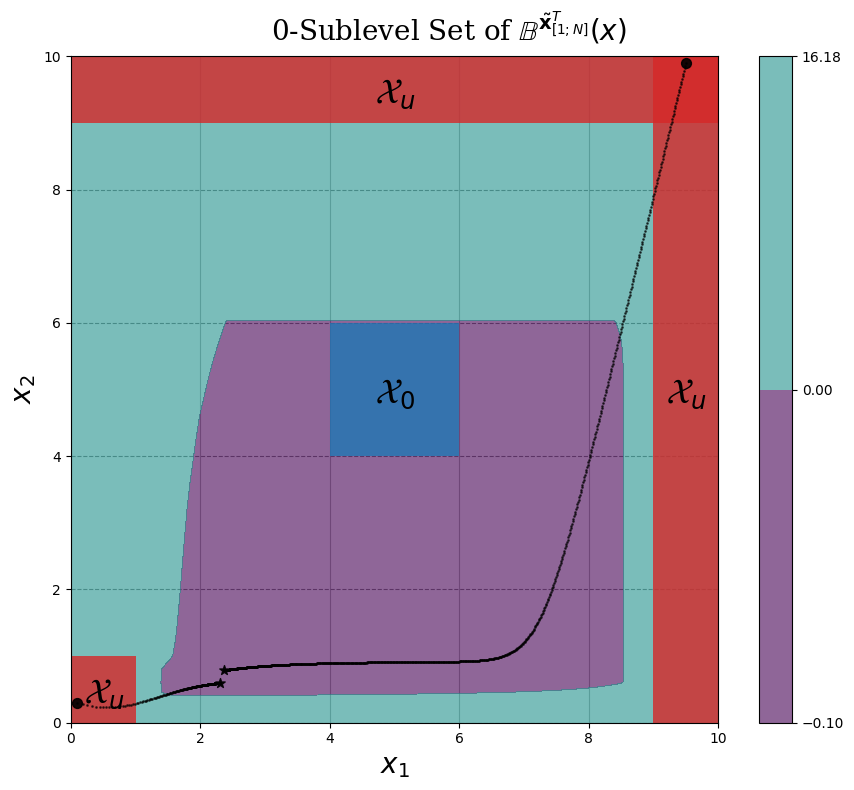

In [ ]:
fig, (ax2) = plt.subplots(figsize = (9,8) )

ax2.set_axisbelow(True)
ax2.yaxis.grid(color='gray', linestyle='dashed')  
ax2.grid(True)

cs = ax2.contourf(X1,X2,BXT,levels=np.array([np.min(BXT),0.00, np.max(BXT)]),alpha=0.6)

# Create a Rectangle patch
for lb, ub in zip(xUlb_list, xUub_list):
    rect = patches.Rectangle((lb[0], lb[1]), ub[0]-lb[0], ub[1]-lb[1], linewidth=2, edgecolor='None', facecolor='tab:red', alpha = 0.8)
    ax2.add_patch(rect)

X0 = patches.Rectangle((x0lb[0], x0lb[1]), x0ub[0]-x0lb[0], x0ub[1]-x0lb[1], linewidth=2, edgecolor='None', facecolor='tab:blue', alpha = 0.8)

ax2.annotate('$\\mathcal{X}_0$',fontsize = 25, color = 'k',xy = ((x0ub[0]+x0lb[0])/2-0.3, (x0ub[1]+x0lb[1])/2-0.2))#math.degrees(math.atan(x0[0]/x0[1])))

for i, (lb, ub) in enumerate(zip(xUlb_list, xUub_list)):
    ax2.annotate(f'$\\mathcal{{X}}_{{u}}$',fontsize = 25, color = 'k',xy = ((ub[0]+lb[0])/2-0.3, (ub[1]+lb[1])/2-0.2))#math.degrees(math.atan(x0[0]/x0[1])))


ax2.text(
        0.0, 1.0, '0-Sublevel Set of $\\mathbb{B}^{\\tilde{\\mathbf{x}}^T_{[1;N]}}(x)$', transform=(
            ax2.transAxes + transforms.ScaledTranslation(+2,+0.1, fig.dpi_scale_trans)),
        fontsize = 20, va='bottom', fontfamily='serif')

# Add the patch to the Axes
ax2.add_patch(X0)
fig.colorbar(cs)


for idx in range(NSol):
    # Plot trajectory as scatter points
    ax2.scatter(trajectory[0, :, idx], trajectory[1, :, idx], s=1, c='black', marker='o', alpha=0.6, zorder=5, label=f'Trajectory {idx}' if idx == 0 else "")
    # Mark start and end points
    ax2.scatter(trajectory[0, 0, idx], trajectory[1, 0, idx], s=50, c='black', marker='o', alpha=0.9, zorder=6, label='Start' if idx == 0 else "")
    ax2.scatter(trajectory[0, -1, idx], trajectory[1, -1, idx], s=50, c='black', marker='*', alpha=0.9, zorder=6, label='End' if idx == 0 else "")

# Add labels, title, and legend
ax2.set_xlabel('$x_1$',fontsize=20)
ax2.set_ylabel('$x_2$',fontsize=20)
#ax2.set_title("Diffusion Barrier Function",fontsize=20)
#ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
#ax2.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax2.axis(bounds[0] + bounds[1])  # Set axis limits based on bounds

#plt.subplots_adjust(hspace=0.5)

plt.tight_layout()
plt.show()



fig.savefig('networkflow_ctrl_B.pdf', format='pdf')